# Supplemental Material
This notebook compares the experimental results of the bivariate beta models using different priors.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
import os

sys.path.append(os.path.abspath('../scripts/python'))
from experiments import starting_experiment


In [17]:
def comparing_methods_panel(true_alphas, prior_configs=None, monte_carlo_size=20, bootstrap_size=500,
                            seed=37812984, name_suffix="supplemental", outdir="../figures"):
    """
    Produce panels (MAPE and Abs Bias) comparing:
      MoM-Closed (MM1), MoM-NLS (MM4), BE-Mean (BE1), BE-Med (BE2)
    across scenarios.
    
    If prior_configs is passed, it compares the 4 different priors for a single true_alpha and n=50.
    Otherwise, it mirrors the standard paper method looping over 4 true_alphas for n=50 and n=200.
    """
    if prior_configs is None:
        ns = [50, 200]
        rows = 2
        cols = 4
        scenarios = true_alphas
        scenario_tags = ['a','b','c','d']
        def _get_fname(col, r):
            return starting_experiment(scenarios[col], ns[r], monte_carlo_size, bootstrap_size, seed)
        def _pretty_title(col, r):
            return rf"({scenario_tags[col]}) $\alpha=({scenarios[col][0]}, {scenarios[col][1]}, {scenarios[col][2]}, {scenarios[col][3]})$"
        def _get_ylab(r):
            return rf"$n={ns[r]}$"
    else:
        ns = [50]
        rows = 1
        cols = len(prior_configs)
        scenarios = prior_configs
        # Describe the priors as titles
        def _get_fname(col, r):
            cfg = scenarios[col]
            return starting_experiment(true_alphas[0], 50, monte_carlo_size, bootstrap_size, seed, **cfg)
        def _pretty_title(col, r):
            cfg = scenarios[col]
            if cfg.get('stan_model') == 'bivariate-beta-model-gamma.stan':
                return fr"$s \sim G({cfg.get('prior_kappa')},{round(cfg.get('prior_lambda'),2)})$"
            elif cfg.get('stan_model') == 'bivariate-beta-model-lognormal.stan':
                return fr"$s \sim LN({cfg.get('prior_mu')},{round(cfg.get('prior_sd'),2)})$"
            return "Custom Prior" 
        def _get_ylab(r):
            return rf"$n=50$"

    keep_idx    = [0, 3, 4, 5]
    keep_labels = ['MoM-Closed', 'MoM-NLS', 'BE-Mean', 'BE-Med']
    
    panel_mape = [[None]*cols for _ in range(rows)]
    panel_bias = [[None]*cols for _ in range(rows)]

    # Run/load experiments and aggregate
    for r in range(rows):
        for col in range(cols):
            fname = _get_fname(col, r)
            if not os.path.exists(fname):
                print(f"File {fname} not found!")
                continue
            with open(fname, "r") as f:
                exp = json.load(f)

            mape_all = np.array([np.mean(m) for m in exp['mape']])
            bias_all = np.array([np.mean(np.abs(b)) for b in exp['bias']])

            panel_mape[r][col] = mape_all[keep_idx]
            panel_bias[r][col] = bias_all[keep_idx]

    def _panel_plot(data_panel, metric_name, fname):
        fig, axes = plt.subplots(rows, cols, figsize=(16, 3*rows + 1), constrained_layout=True, sharey=True)
        if rows == 1 and cols > 1:
            axes = np.array([axes]) # ensure 2D indexing
        elif rows == 1 and cols == 1:
            axes = np.array([[axes]])

        for r in range(rows):
            for c in range(cols):
                ax = axes[r, c]
                vals = data_panel[r][c]
                if vals is None:
                    continue
                x = np.arange(len(keep_labels))
                bars = ax.bar(x, vals)

                ax.set_xticks(x)
                ax.set_xticklabels(keep_labels, rotation=20, ha='right', fontsize=16)
                ax.grid(axis='y', alpha=0.2)
                ax.tick_params(axis='y', labelsize=16)
                
                if c == 0:
                    ax.set_ylabel(_get_ylab(r), fontsize=20)
                if r == 0:
                    ax.set_title(_pretty_title(c, r), fontsize=16)

        os.makedirs(outdir, exist_ok=True)
        path = os.path.join(outdir, fname)
        fig.savefig(path, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        return path

    mape_path = _panel_plot(panel_mape, "MAPE", f"mape_panel_{name_suffix}.pdf")
    bias_path = _panel_plot(panel_bias, "Absolute Bias", f"bias_panel_{name_suffix}.pdf")

    return mape_path, bias_path


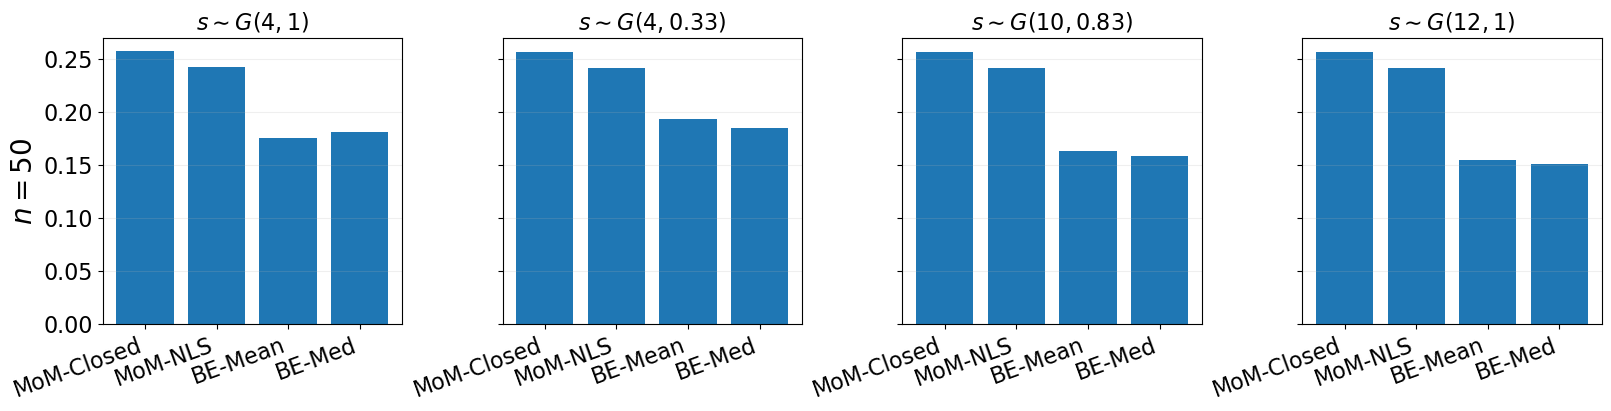

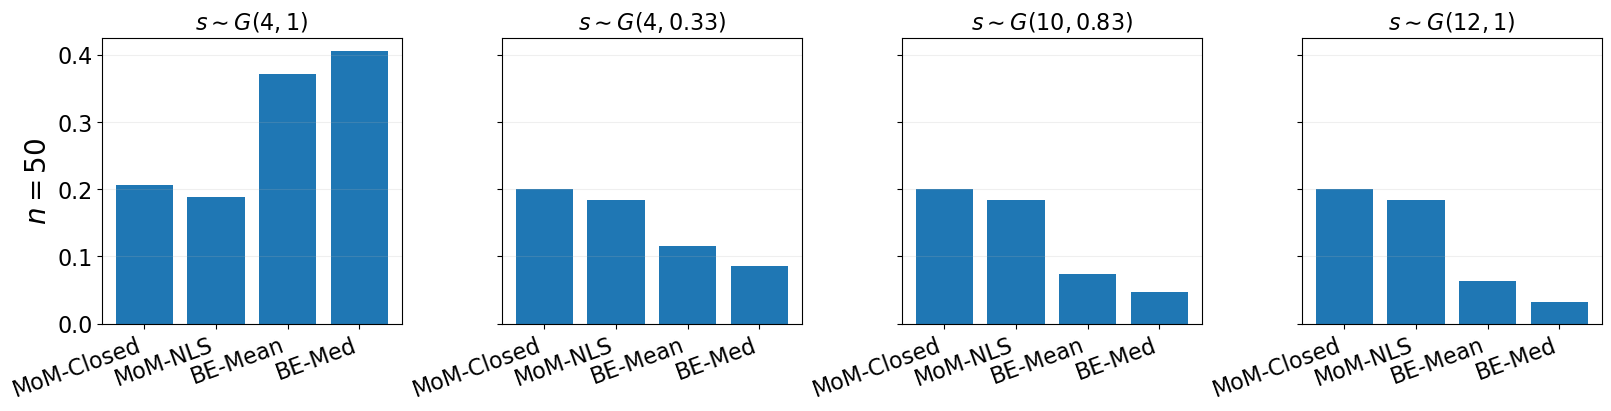

('../figures/mape_panel_scenario_c_supplementary.pdf.pdf',
 '../figures/bias_panel_scenario_c_supplementary.pdf.pdf')

In [19]:
# Define the true alpha array and the 4 specific prior configurations
true_alphas_custom = [np.array([1.0, 7.4, 2.6, 1.0])]

priors = [
    {'stan_model': 'bivariate-beta-model-gamma.stan', 'prior_a': np.array([1, 1, 1, 1]), 'prior_kappa': 4, 'prior_lambda': 1},
    {'stan_model': 'bivariate-beta-model-gamma.stan', 'prior_a': np.array([1, 1, 1, 1]), 'prior_kappa': 4, 'prior_lambda': 1/3},
    {'stan_model': 'bivariate-beta-model-gamma.stan', 'prior_a': np.array([1, 6, 2, 1]), 'prior_kappa': 10, 'prior_lambda': 5/6},
    {'stan_model': 'bivariate-beta-model-gamma.stan', 'prior_a': np.array([1, 7.4, 2.6, 1]), 'prior_kappa': 12, 'prior_lambda': 1}
]

comparing_methods_panel(true_alphas_custom, prior_configs=priors, monte_carlo_size=1000, name_suffix="scenario_c_supplementary.pdf")


## Simulation-Based Calibration (Lognormal Reparameterization)
Here we generate the rank statistic histograms and divergence plots for the lognormal reparameterization model.

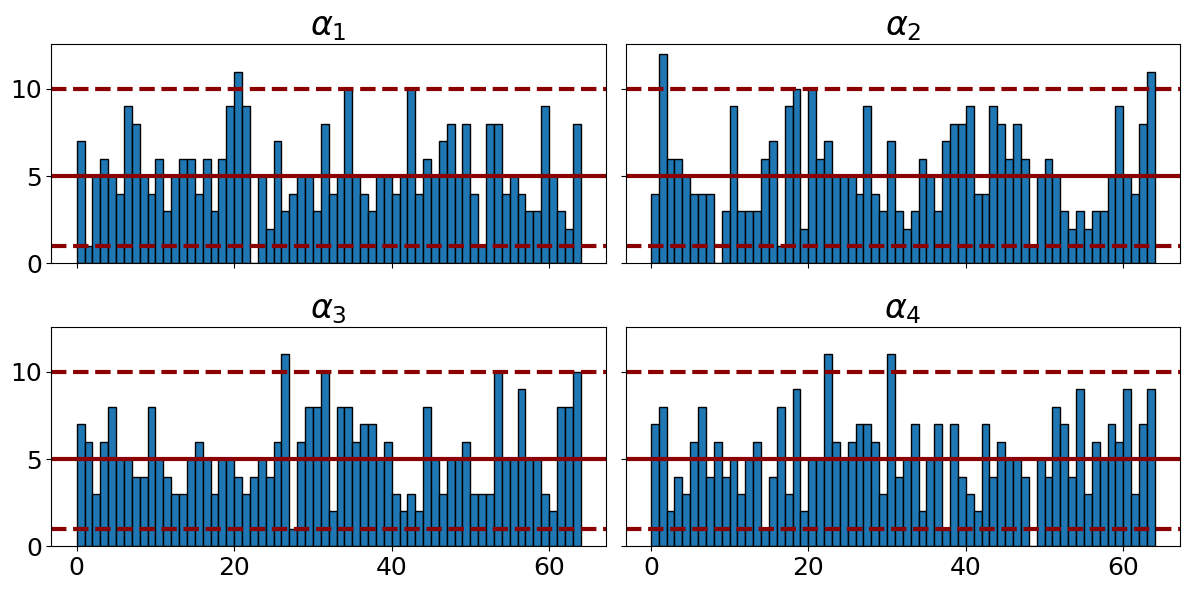

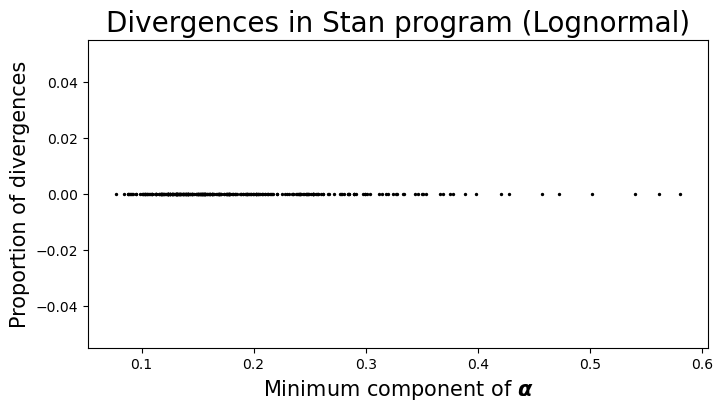

In [7]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Ensure the SBC JSON exists before loading
sbc_file = '../experiments/sbc/sbc_lognormal_a1.0_mu1_sd0.5_50_63_1000_831290.json'
if os.path.exists(sbc_file):
    with open(sbc_file, 'r') as f:
        rho_values = json.load(f)
        
    L = 63
    fig, ax = plt.subplots(2,2,figsize=(12,6), sharex=True, sharey=True)
    for i in range(2):
        for j in range(2):
            ax[i,j].axhline(binom(n=len(rho_values), p=1/(L+1)).ppf(0.025), color='darkred', linestyle='--', linewidth=3)
            ax[i,j].axhline(binom(n=len(rho_values), p=1/(L+1)).ppf(0.5), color='darkred', linestyle='-', linewidth=3)
            ax[i,j].axhline(binom(n=len(rho_values), p=1/(L+1)).ppf(0.975), color='darkred', linestyle='--', linewidth=3)
            ax[i,j].tick_params(axis='x', labelsize=18)
            ax[i,j].tick_params(axis='y', labelsize=18)

    for i in range(4):
        ax[i//2,i%2].hist(np.array([val['rho'] for val in rho_values])[:,i], edgecolor='black', bins=range(L+2))
        ax[i//2,i%2].set_title(r'$\alpha_{}$'.format(i+1), fontsize=24)
        
    plt.tight_layout()
    plt.savefig('../figures/sbc_lognormal_rank_statistic.pdf', bbox_inches='tight')
    plt.show()
    
    for i in rho_values:
        txt = "\n\nChecking sampler transitions for divergences.\n"
        diagnose = i['diagnose']
        pos = diagnose.find(txt)
        divergences = diagnose[pos+len(txt):].split()[0]
        if divergences == 'No':
            divergences = 0
        else:
            divergences = int(divergences)
        i['divergences'] = divergences
        
    values = np.zeros((len(rho_values), 2))
    for i in range(len(rho_values)):
        values[i,0] = min(rho_values[i]['true_alpha'])
        values[i,1] = rho_values[i]['divergences']
        
    plt.figure(figsize=(8,4))
    plt.scatter(values[:,0], values[:,1]/1000, s=2, color='black')
    plt.xlabel(r'Minimum component of $\boldsymbol{\alpha}$', fontsize=15)
    plt.ylabel('Proportion of divergences', fontsize=15)
    plt.title('Divergences in Stan program (Lognormal)', fontsize=20)
    plt.savefig('../figures/sbc_lognormal_divergences.pdf', bbox_inches='tight')
    plt.show()
else:
    print(f"File {sbc_file} not found. Please run experiments.py to generate it.")


## Sensitivity of Calibration Threshold $c$ to Sample Size $n$

A reviewer noted that it is important to understand how the threshold $c$ behaves as the sample size $n$ increases. Intuitively, as $n \to \infty$, the MoM estimator becomes more precise. Since $M$ is strictly positive under the null hypothesis, its sampling distribution (and thus its quantiles) should shift to the right, making a fixed negative threshold like $c = -0.05$ increasingly conservative.

The following simulation computes the distribution of the 5th percentile of $M$ for $n \in \{50, 100, 200\}$ using 2,000 scenarios per sample size (with $\alpha \sim \text{Uniform}(0, 0.5)^4$).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
import os
import sys
sys.path.insert(0, os.path.abspath("../scripts/python"))
from parameter_estimation import BivariateBeta

rng = np.random.default_rng(671289)``
n_values = [10, 20, 50, 100, 200]
num_scenarios = 10000
bootstrap_size = 500

results = {}

for n in n_values:
    print(f"Simulating n={n}...")
    q5_list = []
    for _ in trange(num_scenarios):
        true_alpha = np.random.uniform(0, 0.5, size=4)
        U = rng.dirichlet(true_alpha, size=n)
        X, Y = U[:,0] + U[:,1], U[:,0] + U[:,2]
        
        m1, m2 = np.mean(X), np.mean(Y)
        if m1 <= 0 or m1 >= 1 or m2 <= 0 or m2 >= 1:
            continue

        dist_M = []
        while len(dist_M) < bootstrap_size:
            idx = np.random.choice(range(n), size=n)
            Xb, Yb = X[idx], Y[idx]
            mb1, mb2 = np.mean(Xb), np.mean(Yb)
            if mb1 <= 0 or mb1 >= 1 or mb2 <= 0 or mb2 >= 1:
                continue
            rho = np.corrcoef(Xb, Yb)[0,1]
            D = rho * np.exp(0.5*(np.log(mb1) + np.log1p(-mb1) + np.log(mb2) + np.log1p(-mb2)))
            M = min(D + mb1*mb2, -D + mb1*(1-mb2), -D + mb2*(1-mb1), D + (1-mb1)*(1-mb2))
            dist_M.append(M)
        
        q5_list.append(np.quantile(dist_M, 0.05))
    results[n] = np.array(q5_list)

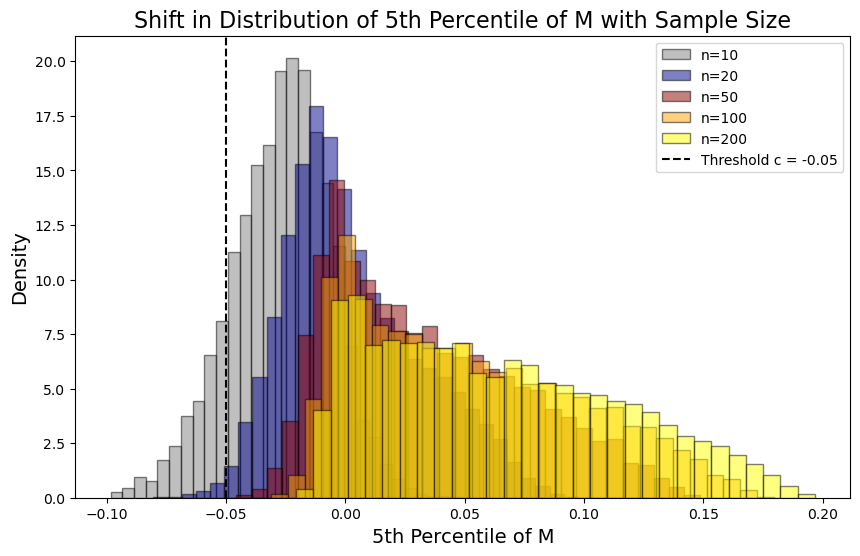

In [23]:
# Plotting
plt.figure(figsize=(10, 6))
colors = ["grey", "darkblue", "darkred", "orange", "yellow"]
for idx, n in enumerate(n_values):
    plt.hist(results[n], bins=30, alpha=0.5, label=f"n={n}", color=colors[idx], edgecolor="black", density=True)

plt.axvline(-0.05, color="black", linestyle="--", label="Threshold c = -0.05")
plt.xlabel("5th Percentile of M", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.title("Shift in Distribution of 5th Percentile of M with Sample Size", fontsize=16)
plt.legend()
plt.savefig("../figures/diagnostic_sensitivity_n.pdf", bbox_inches="tight")
plt.show()